In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Preprocessing

In [8]:
import zipfile
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os # Import os for path manipulation

# Define the path to the zip archive. Assuming it's in the root of 'My Drive'.
# If your 'archive.zip' is in a different location within your Google Drive, please update this path.
zip_file_path = '/content/archive.zip' # User provided path
csv_file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
csv_extracted_path = os.path.join('/content/', csv_file_name)

# Unzip the archive
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"Successfully extracted '{zip_file_path}' to '/content/'")
except FileNotFoundError:
    print(f"Error: The zip file '{zip_file_path}' was not found. Please ensure 'archive.zip' is in the root of your Google Drive or update the 'zip_file_path' variable.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid further errors
except Exception as e:
    print(f"An error occurred during unzipping '{zip_file_path}': {e}")
    df = pd.DataFrame()

# Load the dataset
if not df.empty or os.path.exists(csv_extracted_path): # Check if df was already created due to error, or if csv exists
    try:
        df = pd.read_csv(csv_extracted_path)
    except FileNotFoundError:
        print(f"Error: The CSV file '{csv_file_name}' was not found after extraction. Please check the name of the CSV file inside the zip archive.")
        df = pd.DataFrame()
    except Exception as e:
        print(f"An error occurred while loading the CSV '{csv_extracted_path}': {e}")
        df = pd.DataFrame()
else:
    print("Skipping CSV loading as zip extraction failed or CSV file is not present.")
    df = pd.DataFrame()

# Display the first few rows and information about the dataset
if not df.empty:
    display(df.head())
    df.info()

Successfully extracted '/content/archive.zip' to '/content/'


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Handle Missing Values and Data Type Conversion

In [9]:
# 'TotalCharges' is object type, convert to numeric. Replace spaces (missing values) with NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values after conversion
missing_values = df.isnull().sum()
print("Missing values after converting TotalCharges:")
print(missing_values[missing_values > 0])

# Fill missing 'TotalCharges' with the median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print("\nMissing values after filling:")
print(df.isnull().sum().sum())

Missing values after converting TotalCharges:
TotalCharges    11
dtype: int64

Missing values after filling:
0


/tmp/ipykernel_1488/3284217299.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


### Remove Customer ID

In [10]:
# Drop the 'customerID' column as it's not useful for prediction
df = df.drop('customerID', axis=1)

print("Shape of DataFrame after dropping customerID:", df.shape)

Shape of DataFrame after dropping customerID: (7043, 20)


### Encode Categorical Data

In [11]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding to binary categorical columns ('gender' and 'Churn')
# 'gender' is binary (Male/Female), 'Churn' is binary (Yes/No)
for col in ['gender', 'Churn']:
    if col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        print(f"Column '{col}' encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Apply One-Hot Encoding to other multi-class categorical columns
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col not in ['gender', 'Churn']], drop_first=True)

print("\nShape of DataFrame after encoding categorical features:", df.shape)
display(df.head())

Column 'gender' encoded: {'Female': np.int64(0), 'Male': np.int64(1)}
Column 'Churn' encoded: {'No': np.int64(0), 'Yes': np.int64(1)}

Shape of DataFrame after encoding categorical features: (7043, 31)


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,1,0,34,56.95,1889.50,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,1,0,2,53.85,108.15,1,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,1,0,45,42.30,1840.75,0,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,0,2,70.70,151.65,1,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### Scale Numerical Data

In [12]:
# Identify numerical columns (excluding the target 'Churn' and already encoded binary 'gender')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in numerical_cols:
    numerical_cols.remove('Churn')
if 'gender' in numerical_cols:
    numerical_cols.remove('gender')

# Apply StandardScaler to numerical columns
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nShape of DataFrame after scaling numerical features:", df.shape)
display(df.head())


Shape of DataFrame after scaling numerical features: (7043, 31)


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-0.439916,-1.277445,-1.160323,-0.994242,0,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,1,-0.439916,0.066327,-0.259629,-0.173244,0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,1,-0.439916,-1.236724,-0.362660,-0.959674,1,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,1,-0.439916,0.514251,-0.746535,-0.194766,0,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,-0.439916,-1.236724,0.197365,-0.940470,1,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Exploratory Data Analysis (EDA)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")


### Churn Distribution

/tmp/ipykernel_1488/1151040867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


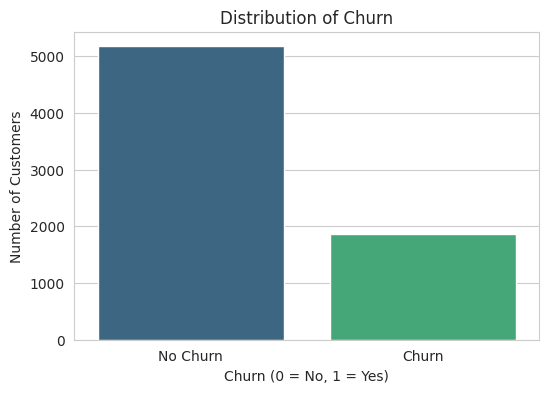

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribution of Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

### Contract vs Churn

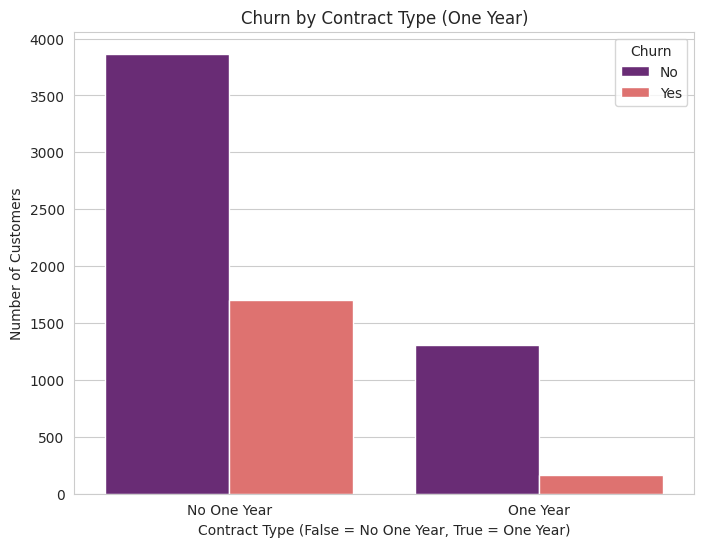

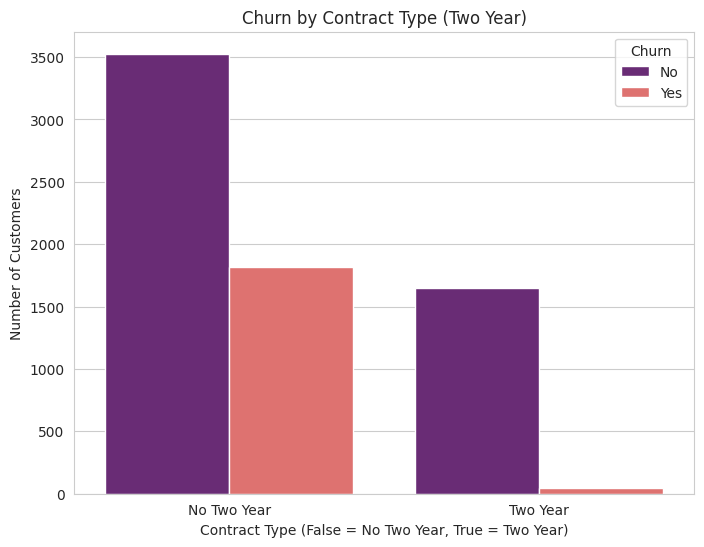

In [15]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract_One year', hue='Churn', data=df, palette='magma')
plt.title('Churn by Contract Type (One Year)')
plt.xlabel('Contract Type (False = No One Year, True = One Year)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No One Year', 'One Year'])
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='Contract_Two year', hue='Churn', data=df, palette='magma')
plt.title('Churn by Contract Type (Two Year)')
plt.xlabel('Contract Type (False = No Two Year, True = Two Year)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Two Year', 'Two Year'])
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

### Tenure vs Churn

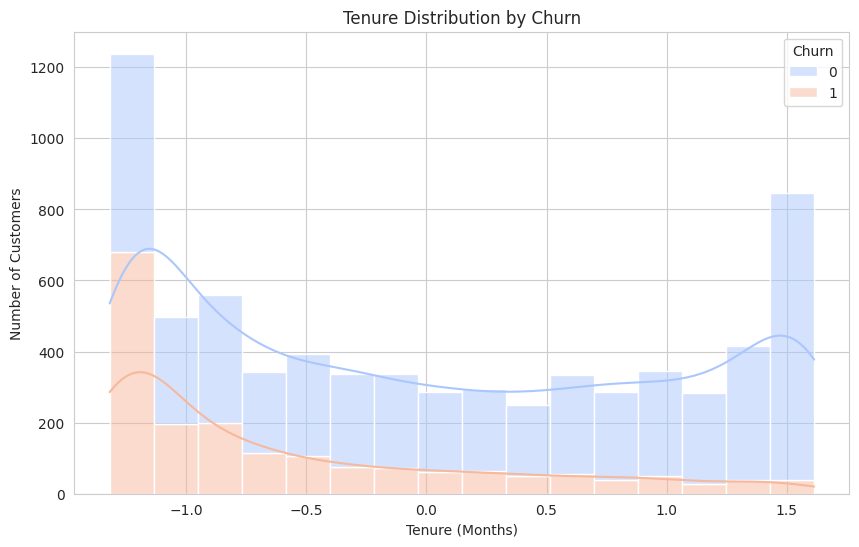

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', kde=True, palette='coolwarm')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Charges vs Churn

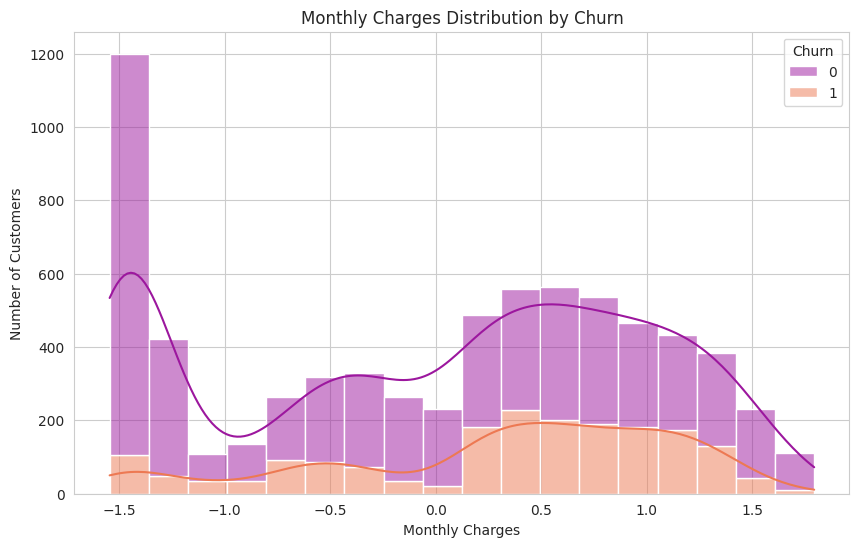

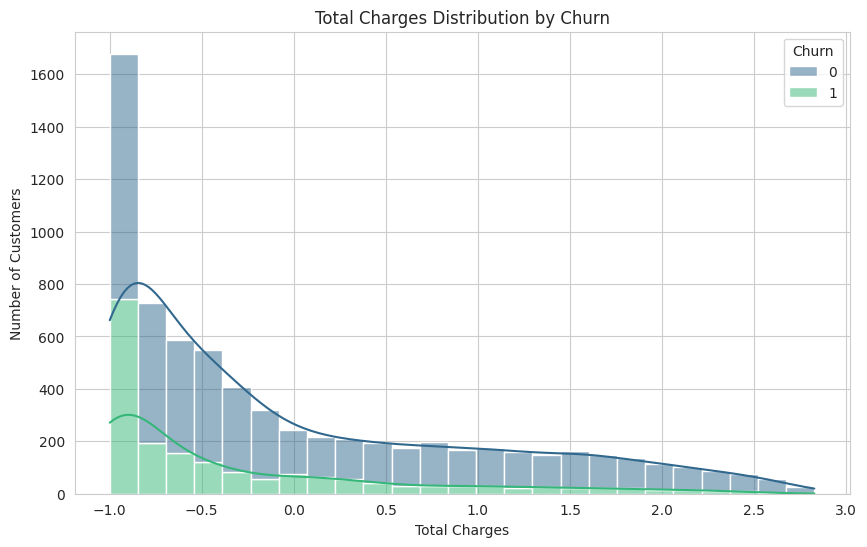

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', kde=True, palette='plasma')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='TotalCharges', hue='Churn', multiple='stack', kde=True, palette='viridis')
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Number of Customers')
plt.show()

## Train / Validation / Test Split

In [18]:
# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split data into training and temporary sets (80% train, 20% temp)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split temporary set into validation and test sets (50% validation, 50% test from temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 30)
y_train shape: (5634,)
X_val shape: (704, 30)
y_val shape: (704,)
X_test shape: (705, 30)
y_test shape: (705,)


## Logistic Regression Baseline Model

Logistic Regression Model Evaluation (Validation Set):
Accuracy: 0.7287
Precision: 0.4933
Recall: 0.7861
F1 Score: 0.6062
ROC-AUC: 0.8493

Confusion Matrix:
[[366 151]
 [ 40 147]]


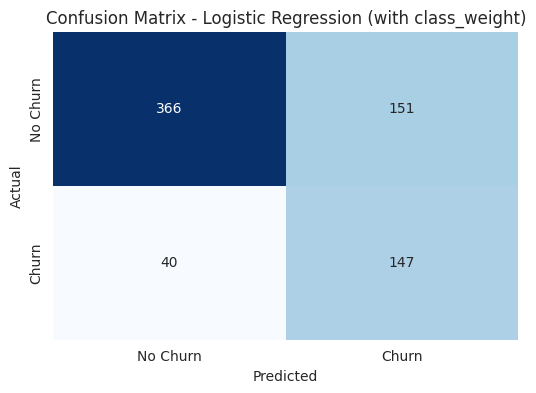

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize and train the Logistic Regression model with class_weight='balanced'
# This helps to address class imbalance by penalizing misclassifications of the minority class more heavily.
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
log_reg_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred_log_reg = log_reg_model.predict(X_val)
y_prob_log_reg = log_reg_model.predict_proba(X_val)[:, 1]

# Evaluate the model
print("Logistic Regression Model Evaluation (Validation Set):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_log_reg):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_log_reg):.4f}")

# Confusion Matrix
conf_matrix_log_reg = confusion_matrix(y_val, y_pred_log_reg)
print("\nConfusion Matrix:")
print(conf_matrix_log_reg)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (with class_weight)')
plt.show()

## Deep Neural Network (DNN) Model

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the DNN model architecture
def build_dnn_model(input_shape):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_shape,)), # Changed from 128 to 64
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2), # Changed from 0.3 to 0.2
        layers.Dense(1, activation='sigmoid') # Output layer for binary classification
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Get input shape from the training data
input_shape = X_train.shape[1]
dnn_model = build_dnn_model(input_shape)

dnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

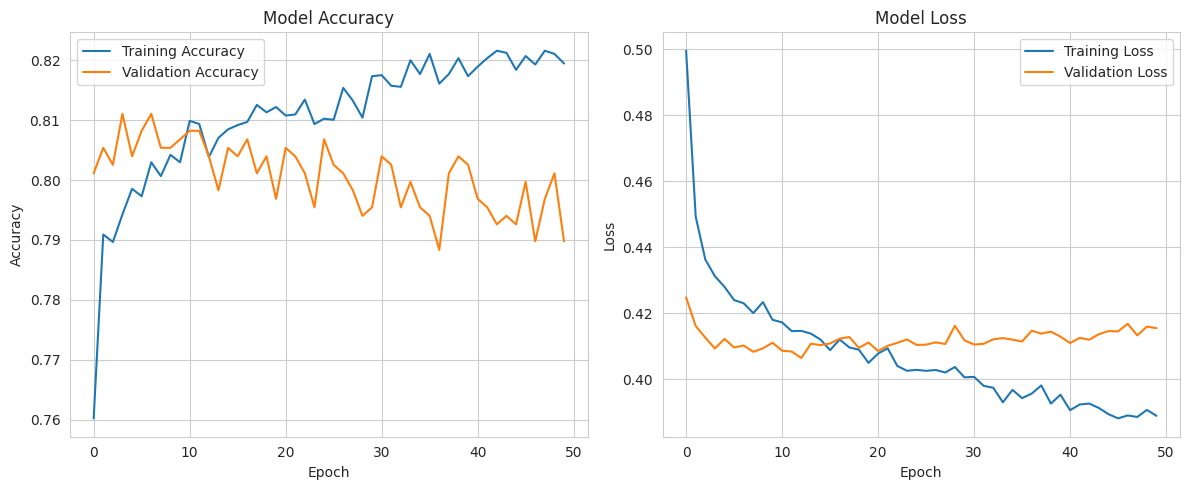

In [21]:
# Train the DNN model
history = dnn_model.fit(X_train, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_data=(X_val, y_val),
                        verbose=0) # Set verbose to 0 to suppress output during training

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Deep Neural Network Model Evaluation (Validation Set):
Accuracy: 0.7898
Precision: 0.6364
Recall: 0.4866
F1 Score: 0.5515
ROC-AUC: 0.8436

Confusion Matrix:
[[465  52]
 [ 96  91]]


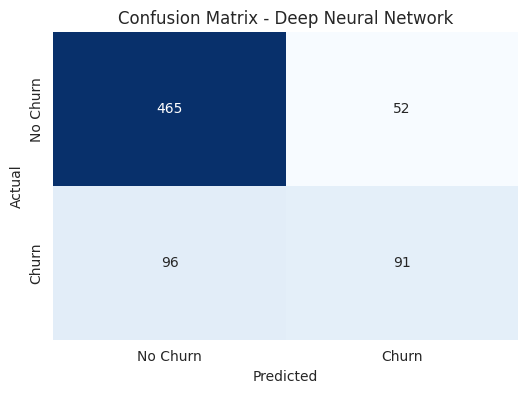

In [22]:
# Make predictions on the validation set
y_prob_dnn = dnn_model.predict(X_val).flatten()
y_pred_dnn = (y_prob_dnn > 0.5).astype(int)

# Evaluate the DNN model
print("Deep Neural Network Model Evaluation (Validation Set):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_dnn):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_dnn):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_dnn):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_dnn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_dnn):.4f}")

# Confusion Matrix
conf_matrix_dnn = confusion_matrix(y_val, y_pred_dnn)
print("\nConfusion Matrix:")
print(conf_matrix_dnn)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_dnn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Deep Neural Network')
plt.show()

## XGBoost Model

XGBoost Model Evaluation (Validation Set):
Accuracy: 0.7500
Precision: 0.5223
Recall: 0.6898
F1 Score: 0.5945
ROC-AUC: 0.8240

Confusion Matrix:
[[399 118]
 [ 58 129]]


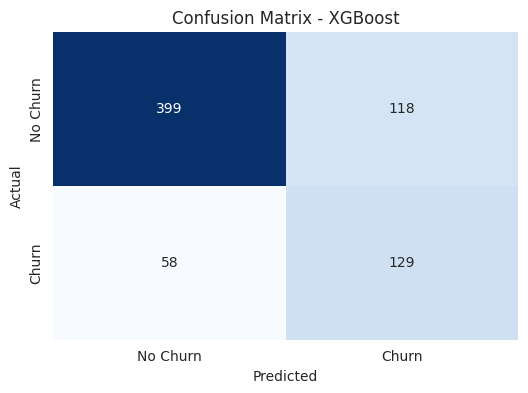

In [23]:
import xgboost as xgb

# Calculate the scale_pos_weight for handling class imbalance
# This is ratio of non-churn customers to churn customers
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Handle class imbalance
)
xgb_model.fit(X_train, y_train)

# Make predictions on the validation set
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

# Evaluate the XGBoost model
print("XGBoost Model Evaluation (Validation Set):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_xgb):.4f}")

# Confusion Matrix
conf_matrix_xgb = confusion_matrix(y_val, y_pred_xgb)
print("\nConfusion Matrix:")
print(conf_matrix_xgb)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

## Model Evaluation

Comparative Model Evaluation (Validation Set):


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7287,0.4933,0.7861,0.6062,0.8493
1,Deep Neural Network,0.7898,0.6364,0.4866,0.5515,0.8436
2,XGBoost,0.7500,0.5223,0.6898,0.5945,0.8240


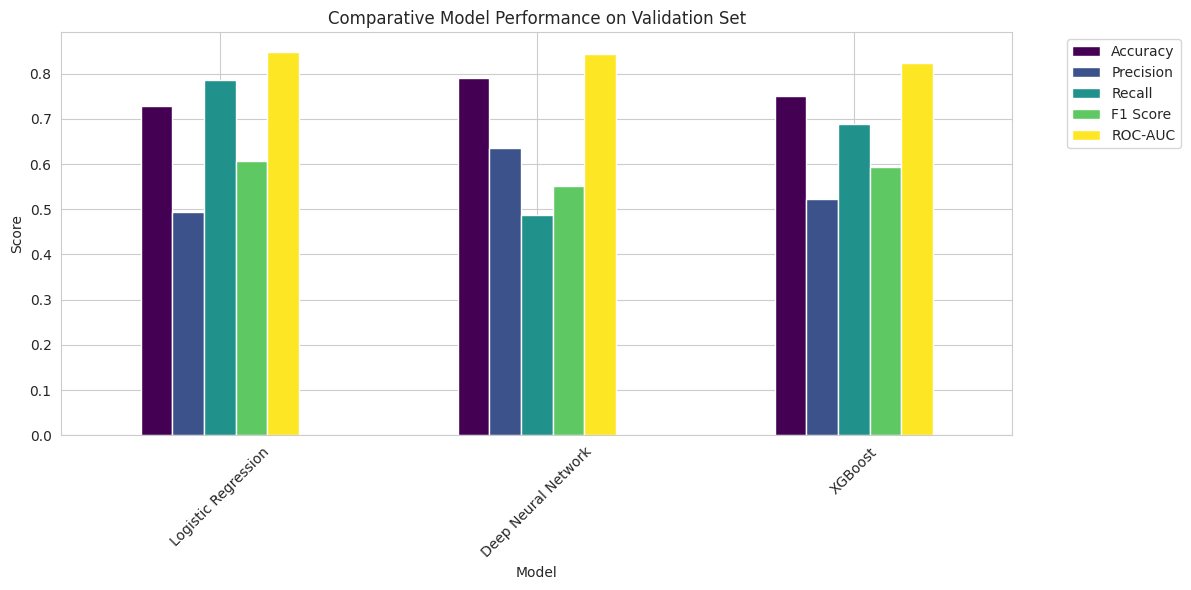

In [24]:
# Compile evaluation metrics for all models

results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC-AUC': []
}

# Logistic Regression Metrics
results['Model'].append('Logistic Regression')
results['Accuracy'].append(accuracy_score(y_val, y_pred_log_reg))
results['Precision'].append(precision_score(y_val, y_pred_log_reg))
results['Recall'].append(recall_score(y_val, y_pred_log_reg))
results['F1 Score'].append(f1_score(y_val, y_pred_log_reg))
results['ROC-AUC'].append(roc_auc_score(y_val, y_prob_log_reg))

# Deep Neural Network Metrics
results['Model'].append('Deep Neural Network')
results['Accuracy'].append(accuracy_score(y_val, y_pred_dnn))
results['Precision'].append(precision_score(y_val, y_pred_dnn))
results['Recall'].append(recall_score(y_val, y_pred_dnn))
results['F1 Score'].append(f1_score(y_val, y_pred_dnn))
results['ROC-AUC'].append(roc_auc_score(y_val, y_prob_dnn))

# XGBoost Metrics
results['Model'].append('XGBoost')
results['Accuracy'].append(accuracy_score(y_val, y_pred_xgb))
results['Precision'].append(precision_score(y_val, y_pred_xgb))
results['Recall'].append(recall_score(y_val, y_pred_xgb))
results['F1 Score'].append(f1_score(y_val, y_pred_xgb))
results['ROC-AUC'].append(roc_auc_score(y_val, y_prob_xgb))


results_df = pd.DataFrame(results)
print("Comparative Model Evaluation (Validation Set):")
display(results_df.round(4))

# Visualize comparison
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Comparative Model Performance on Validation Set')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Churn Risk Prediction

'Logistic Regression' performs best based on ROC-AUC, choosing it for final predictions.

Sample of Churn Risk Predictions on the Test Set:


,Actual Churn,Churn Probability,Risk Category
0,0,0.878883,High Risk
1,0,0.251135,Low Risk
2,1,0.029808,Low Risk
3,1,0.370857,Low Risk
4,0,0.229155,Low Risk


/tmp/ipykernel_1488/3989734788.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk Category', data=churn_predictions_df, palette='YlOrRd', order=['Low Risk', 'Medium Risk', 'High Risk'])


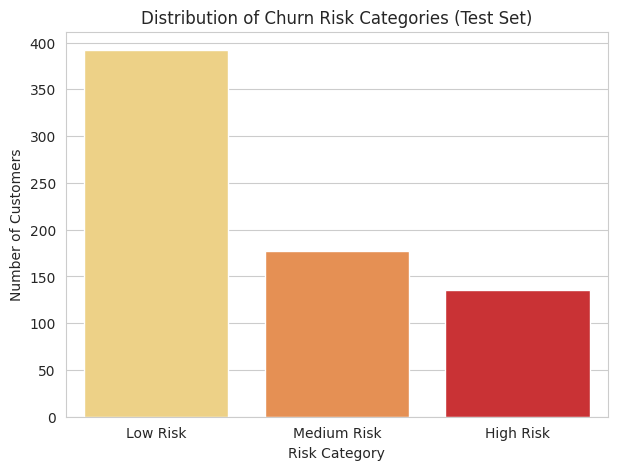

In [25]:
best_model = None
best_model_name = ''
max_roc_auc = -1

# Find the model with the highest ROC-AUC from the results_df
for index, row in results_df.iterrows():
    if row['ROC-AUC'] > max_roc_auc:
        max_roc_auc = row['ROC-AUC']
        best_model_name = row['Model']

# Assign the corresponding model object
if best_model_name == 'Logistic Regression':
    best_model = log_reg_model
elif best_model_name == 'Deep Neural Network':
    best_model = dnn_model
elif best_model_name == 'XGBoost':
    best_model = xgb_model

print(f"'{best_model_name}' performs best based on ROC-AUC, choosing it for final predictions.")

# Predict probabilities for the test set using the best_model
# Need to handle different predict_proba/predict methods for different model types
if isinstance(best_model, LogisticRegression):
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
elif isinstance(best_model, tf.keras.models.Sequential):
    y_test_prob = best_model.predict(X_test).flatten()
elif isinstance(best_model, xgb.XGBClassifier):
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
else:
    print("Unsupported best model type for prediction.")
    raise TypeError("Model type not supported for final predictions.")

# Create a DataFrame for churn risk prediction on the test set
churn_predictions_df = pd.DataFrame({
    'Actual Churn': y_test.values,
    'Churn Probability': y_test_prob
})

# Define risk categories based on probability thresholds
def categorize_risk(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.45:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_predictions_df['Risk Category'] = churn_predictions_df['Churn Probability'].apply(categorize_risk)

print("\nSample of Churn Risk Predictions on the Test Set:")
display(churn_predictions_df.head())

# Distribution of Risk Categories
plt.figure(figsize=(7, 5))
sns.countplot(x='Risk Category', data=churn_predictions_df, palette='YlOrRd', order=['Low Risk', 'Medium Risk', 'High Risk'])
plt.title('Distribution of Churn Risk Categories (Test Set)')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')
plt.show()

## Retention Strategy Engine

In [26]:
def recommend_retention_strategy(customer_data, churn_probability, risk_category):
    strategy = []

    if risk_category == 'High Risk':
        strategy.append('Personalized Offer (e.g., significant discount on monthly bill or free premium service for a period)')
        if customer_data['Contract_Two year'].iloc[0] == 0: # If not on a two-year contract
            strategy.append('Contract Upgrade (e.g., offer incentives for a longer-term contract)')
        if customer_data['TechSupport_Yes'].iloc[0] == 0: # If no tech support
            strategy.append('Enhanced Customer Support (e.g., dedicated support line, proactive check-ins)')

    elif risk_category == 'Medium Risk':
        strategy.append('Discount (e.g., small discount on monthly bill or offer bundled services)')
        if customer_data['InternetService_Fiber optic'].iloc[0] == 1: # If fiber optic customer, prone to churn
             strategy.append('Service Improvement Communication (e.g., highlight benefits of current services or new features)')
        if customer_data['PaperlessBilling_Yes'].iloc[0] == 1: # Paperless billing often linked to electronic check and higher churn
             strategy.append('Payment Method Review (e.g., suggest alternative, more stable payment methods)')

    else: # Low Risk
        strategy.append('Loyalty Program Engagement (e.g., points, exclusive content, or small perks)')
        strategy.append('Customer Feedback Survey (e.g., gather insights to maintain satisfaction)')

    return '; '.join(strategy) if strategy else 'No specific strategy recommended.'

# Create a DataFrame for test customers with their original features for strategy recommendation
# We need to map back to original categorical values for interpretability if needed for specific rules.
# For this example, we'll use the one-hot encoded features directly as rules are based on their binary values.

# Get random *positional* indices for the test set
import numpy as np
num_samples = 5
random_positional_indices = np.random.choice(len(X_test), num_samples, replace=False)

sample_customers_data = X_test.iloc[random_positional_indices]
sample_predictions = churn_predictions_df.iloc[random_positional_indices]

# The original indices of the sampled customers from the full dataset
sample_original_indices = X_test.iloc[random_positional_indices].index

# Combine sample data and predictions for easier processing
sample_combined = sample_customers_data.copy()
sample_combined['Actual Churn'] = sample_predictions['Actual Churn'].values
sample_combined['Churn Probability'] = sample_predictions['Churn Probability'].values
sample_combined['Risk Category'] = sample_predictions['Risk Category'].values

# Set the index of sample_combined to the original indices for easier lookup and context
sample_combined.index = sample_original_indices

print("\nRetention Strategy Recommendations for Sample Customers:")
recommended_strategies = []
for idx, row in sample_combined.iterrows():
    customer_features = pd.DataFrame(row).transpose() # Convert row to DataFrame for consistency with previous access
    strategy = recommend_retention_strategy(customer_features, row['Churn Probability'], row['Risk Category'])
    recommended_strategies.append({
        'Customer Index': idx,
        'Churn Probability': f"{row['Churn Probability']:.2f}",
        'Risk Category': row['Risk Category'],
        'Recommended Action': strategy
    })

recommended_strategies_df = pd.DataFrame(recommended_strategies)
display(recommended_strategies_df)


Retention Strategy Recommendations for Sample Customers:


,Customer Index,Churn Probability,Risk Category,Recommended Action
0,954,0.88,High Risk,"Personalized Offer (e.g., significant discount..."
1,2373,0.05,Low Risk,"Loyalty Program Engagement (e.g., points, excl..."
2,150,0.68,Medium Risk,"Discount (e.g., small discount on monthly bill..."
3,522,0.46,Medium Risk,"Discount (e.g., small discount on monthly bill..."
4,2949,0.06,Low Risk,"Loyalty Program Engagement (e.g., points, excl..."


## AI Agent Layer (Conceptual - using Gemini API for advanced insights)

In [27]:
# This section is conceptual and demonstrates how a Gemini API call would integrate.
# In a real-world scenario, you would replace this with actual API calls.

# Robustness check: Ensure sample_combined and recommended_strategies_df are available
if 'sample_combined' not in globals() or 'recommended_strategies_df' not in globals():
    print("Error: 'sample_combined' or 'recommended_strategies_df' not found. Please run the preceding cell (Retention Strategy Engine - cc94f97c) first to generate sample customer data and strategies.")
    # Exit the cell or define dummy variables to prevent further NameErrors if running in an isolated environment.
    # For this exercise, we'll assume the user will re-run the previous cell.
    raise NameError("Required variables not defined. Please run cell cc94f97c.")

def generate_ai_insights(customer_data_row, churn_probability, risk_category, recommended_action):
    # Simulate AI API call using a placeholder function
    # In a real scenario, this would involve sending data to Gemini API
    # and processing its natural language understanding and generation capabilities.

    summary = f"Customer (Index: {customer_data_row.name}) has a churn probability of {churn_probability:.2f}, categorized as {risk_category}."
    explanation = f"Key factors contributing to this risk often include contract type, monthly charges, and tenure. Specific details based on the customer's profile would be extracted here."
    action_rationale = f"The recommended action '{recommended_action}' is designed to address identified churn drivers for {risk_category} customers."

    # Example of how Gemini might explain a prediction
    # Access 'Contract_Month-to-month' directly from the customer_data_row Series
    if customer_data_row.get('Contract_Month-to-month', 0) == 1: # Use .get for safety, assuming 0 if column is missing
         explanation += " This customer is on a month-to-month contract, which is typically associated with higher churn rates."

    # Example of how Gemini might recommend an action based on context
    if 'Discount' in recommended_action:
        action_rationale += " A discount is suggested as it can directly improve customer satisfaction and reduce perceived cost, especially effective for customers sensitive to price."

    return {
        'Summary': summary,
        'Explanation': explanation,
        'AI Action Rationale': action_rationale # Corrected key name to match previous output structure
    }

# Generate AI insights for the sample customers
ai_insights_list = []
for idx, row in sample_combined.iterrows():
    # Find the corresponding recommended action for the current customer index
    action = recommended_strategies_df[recommended_strategies_df['Customer Index'] == idx]['Recommended Action'].iloc[0]

    # Pass the entire 'row' (which contains all features and risk info) as customer_data_row
    insights = generate_ai_insights(row, row['Churn Probability'], row['Risk Category'], action)
    ai_insights_list.append({
        'Customer Index': idx,
        'Churn Probability': f"{row['Churn Probability']:.2f}",
        'Risk Category': row['Risk Category'],
        'Recommended Action': action,
        'AI Summary': insights['Summary'],
        'AI Explanation': insights['Explanation'],
        'AI Action Rationale': insights['AI Action Rationale']
    })

ai_insights_df = pd.DataFrame(ai_insights_list)
print("\nAI-generated Insights for Sample Customers:")
display(ai_insights_df)


AI-generated Insights for Sample Customers:


,Customer Index,Churn Probability,Risk Category,Recommended Action,AI Summary,AI Explanation,AI Action Rationale
0,954,0.88,High Risk,"Personalized Offer (e.g., significant discount...",Customer (Index: 954) has a churn probability ...,Key factors contributing to this risk often in...,The recommended action 'Personalized Offer (e....
1,2373,0.05,Low Risk,"Loyalty Program Engagement (e.g., points, excl...",Customer (Index: 2373) has a churn probability...,Key factors contributing to this risk often in...,The recommended action 'Loyalty Program Engage...
2,150,0.68,Medium Risk,"Discount (e.g., small discount on monthly bill...",Customer (Index: 150) has a churn probability ...,Key factors contributing to this risk often in...,"The recommended action 'Discount (e.g., small ..."
3,522,0.46,Medium Risk,"Discount (e.g., small discount on monthly bill...",Customer (Index: 522) has a churn probability ...,Key factors contributing to this risk often in...,"The recommended action 'Discount (e.g., small ..."
4,2949,0.06,Low Risk,"Loyalty Program Engagement (e.g., points, excl...",Customer (Index: 2949) has a churn probability...,Key factors contributing to this risk often in...,The recommended action 'Loyalty Program Engage...


## Final Output

In [28]:
# Combine all information for the final output for sample customers
final_output_df = ai_insights_df.copy()
final_output_df.set_index('Customer Index', inplace=True)

print("\nFinal Churn Prediction and Retention Output for Sample Customers:")
display(final_output_df)


Final Churn Prediction and Retention Output for Sample Customers:


,Churn Probability,Risk Category,Recommended Action,AI Summary,AI Explanation,AI Action Rationale
Customer Index,,,,,,
954,0.88,High Risk,"Personalized Offer (e.g., significant discount...",Customer (Index: 954) has a churn probability ...,Key factors contributing to this risk often in...,The recommended action 'Personalized Offer (e....
2373,0.05,Low Risk,"Loyalty Program Engagement (e.g., points, excl...",Customer (Index: 2373) has a churn probability...,Key factors contributing to this risk often in...,The recommended action 'Loyalty Program Engage...
150,0.68,Medium Risk,"Discount (e.g., small discount on monthly bill...",Customer (Index: 150) has a churn probability ...,Key factors contributing to this risk often in...,"The recommended action 'Discount (e.g., small ..."
522,0.46,Medium Risk,"Discount (e.g., small discount on monthly bill...",Customer (Index: 522) has a churn probability ...,Key factors contributing to this risk often in...,"The recommended action 'Discount (e.g., small ..."
2949,0.06,Low Risk,"Loyalty Program Engagement (e.g., points, excl...",Customer (Index: 2949) has a churn probability...,Key factors contributing to this risk often in...,The recommended action 'Loyalty Program Engage...


### Final Evaluation of Best Model on Test Set


Overall Evaluation Metrics for Chosen Best Model (Logistic Regression) on Test Set:


,Metric,Your model
0,Accuracy,0.7475
1,Precision,0.5159
2,Recall,0.7807
3,F1-score,0.6213
4,ROC-AUC,0.8347


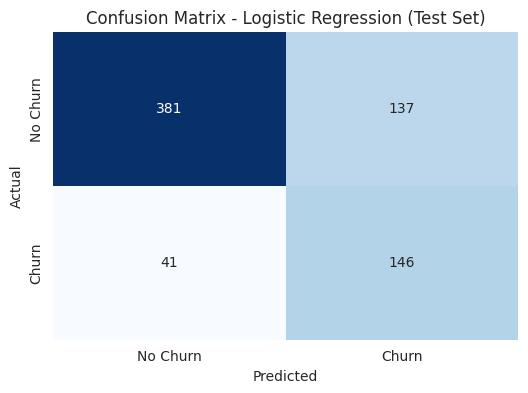

In [29]:
# Evaluate the best_model on the test set

# Ensure best_model is defined
if 'best_model' not in globals():
    print("Error: 'best_model' not found. Please ensure the 'Churn Risk Prediction' cell (bb56e67f) has been run.")
    raise NameError("'best_model' not defined.")

# Predict probabilities for the test set using the best_model
if isinstance(best_model, LogisticRegression):
    y_test_prob_final = best_model.predict_proba(X_test)[:, 1]
    y_test_pred_final = (y_test_prob_final > 0.5).astype(int) # Using default 0.5 threshold
elif isinstance(best_model, tf.keras.models.Sequential):
    y_test_prob_final = best_model.predict(X_test).flatten()
    y_test_pred_final = (y_test_prob_final > 0.5).astype(int)
elif isinstance(best_model, xgb.XGBClassifier):
    y_test_prob_final = best_model.predict_proba(X_test)[:, 1]
    y_test_pred_final = (y_test_prob_final > 0.5).astype(int)
else:
    print("Unsupported model type for final evaluation.")
    raise TypeError("Model type not supported for final evaluation.")

# Calculate metrics
accuracy_final = accuracy_score(y_test, y_test_pred_final)
precision_final = precision_score(y_test, y_test_pred_final)
recall_final = recall_score(y_test, y_test_pred_final)
f1_final = f1_score(y_test, y_test_pred_final)
roc_auc_final = roc_auc_score(y_test, y_test_prob_final)

# Create a DataFrame for final metrics
final_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Your model': [accuracy_final, precision_final, recall_final, f1_final, roc_auc_final]
})

print(f"\nOverall Evaluation Metrics for Chosen Best Model ({best_model_name}) on Test Set:")
display(final_metrics_df.round(4))

# Optional: Display confusion matrix for the test set
conf_matrix_final = confusion_matrix(y_test, y_test_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name} (Test Set)')
plt.show()

In [30]:
# ==========================================
# SAVE MODEL AND PREPROCESSING FOR STREAMLIT
# ==========================================

import joblib

# 1. Save the trained Logistic Regression model
joblib.dump(log_reg_model, "churn_model.pkl")

# 2. Save the StandardScaler
joblib.dump(scaler, "churn_scaler.pkl")

# 3. Save the exact feature column order used by the model
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

# 4. Save the numerical columns that were scaled
joblib.dump(numerical_cols, "numerical_columns.pkl")

# 5. Save the median used for missing TotalCharges
totalcharges_median = df["TotalCharges"].median()
joblib.dump(totalcharges_median, "totalcharges_median.pkl")

print("✅ Model and preprocessing files saved successfully!")
print()
print("Files created:")
print("1. churn_model.pkl")
print("2. churn_scaler.pkl")
print("3. feature_columns.pkl")
print("4. numerical_columns.pkl")
print("5. totalcharges_median.pkl")
print()
print("Number of model features:", len(feature_columns))

✅ Model and preprocessing files saved successfully!

Files created:
1. churn_model.pkl
2. churn_scaler.pkl
3. feature_columns.pkl
4. numerical_columns.pkl
5. totalcharges_median.pkl

Number of model features: 30


In [31]:
!pip install -q gradio

In [32]:
import gradio as gr
import pandas as pd
import numpy as np

def predict_churn(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    # Create input dataframe
    customer = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges
    }])

    # Convert TotalCharges to numeric
    customer["TotalCharges"] = pd.to_numeric(
        customer["TotalCharges"],
        errors="coerce"
    )

    # Fill missing TotalCharges using training median
    customer["TotalCharges"] = customer["TotalCharges"].fillna(
        totalcharges_median
    )

    # Encode gender exactly as training
    customer["gender"] = customer["gender"].map({
        "Female": 0,
        "Male": 1
    })

    # One-hot encode categorical columns
    customer = pd.get_dummies(
        customer,
        columns=[
            "Partner",
            "Dependents",
            "PhoneService",
            "MultipleLines",
            "InternetService",
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies",
            "Contract",
            "PaperlessBilling",
            "PaymentMethod"
        ],
        drop_first=True
    )

    # Make columns exactly match training
    customer = customer.reindex(
        columns=feature_columns,
        fill_value=0
    )

    # Scale numerical columns
    customer[numerical_cols] = scaler.transform(
        customer[numerical_cols]
    )

    # Prediction
    probability = log_reg_model.predict_proba(customer)[0][1]

    # Risk
    if probability < 0.30:
        risk = "🟢 LOW"
        recommendation = "Maintain regular engagement and offer loyalty benefits."
    elif probability < 0.60:
        risk = "🟡 MEDIUM"
        recommendation = "Offer a personalized retention offer and monitor the customer."
    else:
        risk = "🔴 HIGH"
        recommendation = "Offer a loyalty discount, proactive support, and encourage a long-term contract."

    return (
        f"### Churn Probability: {probability*100:.2f}%\n\n"
        f"### Risk Level: {risk}\n\n"
        f"### Recommended Action\n{recommendation}"
    )

In [33]:
demo = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Dropdown(["Female", "Male"], label="Gender"),
        gr.Dropdown([0, 1], label="Senior Citizen"),
        gr.Dropdown(["Yes", "No"], label="Partner"),
        gr.Dropdown(["Yes", "No"], label="Dependents"),
        gr.Number(label="Tenure (months)", value=12),
        gr.Dropdown(["Yes", "No"], label="Phone Service"),
        gr.Dropdown(
            ["No phone service", "No", "Yes"],
            label="Multiple Lines"
        ),
        gr.Dropdown(
            ["DSL", "Fiber optic", "No"],
            label="Internet Service"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Online Security"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Online Backup"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Device Protection"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Tech Support"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Streaming TV"
        ),
        gr.Dropdown(
            ["No internet service", "No", "Yes"],
            label="Streaming Movies"
        ),
        gr.Dropdown(
            ["Month-to-month", "One year", "Two year"],
            label="Contract"
        ),
        gr.Dropdown(["Yes", "No"], label="Paperless Billing"),
        gr.Dropdown(
            [
                "Electronic check",
                "Mailed check",
                "Bank transfer (automatic)",
                "Credit card (automatic)"
            ],
            label="Payment Method"
        ),
        gr.Number(label="Monthly Charges", value=70),
        gr.Number(label="Total Charges", value=840)
    ],
    outputs=gr.Markdown(),
    title="📊 Customer Churn AI Agent",
    description="Predict customer churn risk and generate a retention recommendation."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6b521d2e837e0dc638.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
